<a href="https://colab.research.google.com/github/peremartra/optipfair/blob/main/examples/knowledge_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OptiPFair Notebook Series - Example: Knowledge Distillation
![optiPfair Logo](https://github.com/peremartra/optipfair/blob/main/images/optiPfair.png?raw=true)
This notebook demonstrates how to use [OptiPFair](https://github.com/peremartra/optipfair) to recover performance after depth pruning using knowledge distillation.  
It follows the full recommended workflow with public APIs only: load a teacher model, create a depth-pruned student, distill knowledge, and visualize training curves.

The benchmark stage with lm_eval is intentionally excluded in this example.

##Recommended Environment

- **Platform**: [Google Colab](https://colab.research.google.com)  
- **Hardware**: GPU A100.
- **Dependencies**: Installed in Section 0

##by Pere Martra.

- [LinkedIn](https://www.linkedin.com/in/pere-martra)  
- [GitHub](https://github.com/peremartra)  
- [X / Twitter](https://x.com/peremartra)

---

> If you find this useful, please ⭐ the [repository](https://github.com/peremartra/optipfair) and share it!

---
If you want your favorite LLM to create code with optiPfair, you just need to provide it with the file: [**optipfair_llm_reference_manual.txt**](https://github.com/peremartra/optipfair/blob/main/optipfair_llm_reference_manual.txt), which contains all the necessary information for the LLM to become an expert in using the library.

# Knowledge Distillation Example

This notebook demonstrates how to recover a depth-pruned model with OptiPFair knowledge distillation.
We follow the recommended sequence for post-pruning recovery:
1. Load a teacher model
2. Prepare a small recovery dataset
3. Build a depth-pruned student with OptiPFair
4. Recover performance with knowledge distillation using `opf.distill_model()`
5. Plot training losses from `stats['loss_history']`

## 0. Environment and Dependencies\n
First, install the required libraries and define the base configuration.

In [1]:
!pip install git+https://github.com/peremartra/optipfair.git

  Cloning https://github.com/peremartra/optipfair.git to /tmp/pip-req-build-8l336rqs
  Running command git clone --filter=blob:none --quiet https://github.com/peremartra/optipfair.git /tmp/pip-req-build-8l336rqs
  Resolved https://github.com/peremartra/optipfair.git to commit e35f61f0d6755bb00d72b85eff91050661e27c7c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for optipfair: filename=optipfair-0.3.0-py3-none-any.whl size=64358 sha256=064e2715c6ad741c10059584113ea8eb108fb8e79b748894c82832ed8489859a
  Stored in directory: /tmp/pip-ephem-wheel-cache-l7lfsqlp/wheels/34/ee/95/45c0e77756d6cde346debec33bab0826fe994bc1baeeda4f31
Successfully built optipfair


In [2]:
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib
!pip install -q lm-eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 126.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 42.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.1/373.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 138.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
RECOVERY_SAMPLES = 2000   # Use a small number for the example\n
EPOCHS = 3
LEARNING_RATE = 4e-5
BATCH_SIZE = 4
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 10

# --- Performance measurement settings (used in Sections 1 and 9) ---
PERF_MAX_NEW_TOKENS = 50
PERF_NUM_RUNS       = 3
PERF_MAX_SAMPLES    = 10

PERF_PROMPT = (
    "The transformer architecture revolutionized natural language processing by introducing"
    " the attention mechanism, which allows the model to focus on relevant parts of the input."
)

PERF_SENTENCES = [
    "The capital of France is",
    "Neural networks learn representations by",
    "The theory of relativity states that",
    "Language models are trained on",
    "Depth pruning reduces the number of layers by",
    "Knowledge distillation transfers information from",
    "The attention mechanism allows transformers to",
    "Gradient descent minimizes the loss function by",
    "The perplexity of a language model measures how",
    "Quantization reduces model size by representing weights in",
]

In [4]:
import torch
from copy import deepcopy
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset, Dataset
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import optipfair as opf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class DictLoader:
    """Wraps a TensorDataset DataLoader to yield dict batches."""
    def __init__(self, dl): self.dl = dl
    def __iter__(self):
        for ids, mask in self.dl:
            yield {"input_ids": ids, "attention_mask": mask}
    def __len__(self): return len(self.dl)

Using device: cuda


## 1. Load Teacher Model
Load the teacher model in evaluation mode and freeze all its parameters.

The teacher is only used as a supervision signal during distillation.

In [5]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B-Base"   # or "google/gemma-3-270m" for a smaller option\n

print(f"Loading Teacher model: {MODEL_NAME}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)

teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

n_teacher_layers = teacher_model.config.num_hidden_layers
teacher_n_params  = teacher_model.num_parameters()
print(f"Teacher: {n_teacher_layers} layers, {teacher_n_params:,} params")

Loading Teacher model: Qwen/Qwen3.5-0.8B-Base


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Teacher: 24 layers, 752,393,024 params


In [6]:
from utils import measure_memory_allocation, measure_detailed_performance

# Build performance loader — tokenizer is now available
perf_enc = tokenizer(
    PERF_SENTENCES,
    padding=True, truncation=True, max_length=64, return_tensors="pt"
)
perf_dataset     = TensorDataset(perf_enc["input_ids"], perf_enc["attention_mask"])
perf_loader      = DataLoader(perf_dataset, batch_size=2)
perf_dict_loader = DictLoader(perf_loader)

# Measure teacher performance (clean GPU — no other model in memory yet)
print("Measuring VRAM (teacher)...")
teacher_vram = measure_memory_allocation(
    teacher_model, tokenizer, PERF_PROMPT, max_new_tokens=PERF_MAX_NEW_TOKENS
)
print("Measuring tokens/sec (teacher)...")
teacher_perf = measure_detailed_performance(
    teacher_model, tokenizer, perf_dict_loader,
    num_runs=PERF_NUM_RUNS, max_new_tokens=PERF_MAX_NEW_TOKENS, max_samples=PERF_MAX_SAMPLES
)
print(f"  Teacher VRAM (static): {teacher_vram['static_vram_mb']:.0f} MB")
print(f"  Teacher throughput:    {teacher_perf['throughput_tokens_per_sec']:.1f} tok/s")

Measuring VRAM (teacher)...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Measuring tokens/sec (teacher)...
🚀 Optimization active: Using Mixed Precision (torch.bfloat16) if available.
Measuring performance on 5 batches (Total samples: 10, 3 runs each)...
   🔥 Performing GPU Warm-up...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:   0%|          | 0/5 [00:00<?, ?it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:  20%|██        | 1/5 [00:07<00:31,  7.79s/it]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only ar

  Teacher VRAM (static): 1435 MB
  Teacher throughput:    38.6 tok/s


## 2. Prepare Training Dataset
Adapted from NB03: load Cosmopedia in streaming mode, tokenize text, and create an 80/20 train/validation split.

In [7]:
print("Loading Cosmopedia dataset...")
dataset_name = "HuggingFaceTB/cosmopedia"
subsets = ["stories", "wikihow", "openstax", "web_samples_v1"]
samples_per_subset = int(RECOVERY_SAMPLES / len(subsets))\

all_samples = []
for subset in subsets:
    print(f"  Loading {subset}...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(samples_per_subset))
    all_samples.extend(subset_samples)
    print(f"    Collected {len(subset_samples):,} samples")

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

Loading Cosmopedia dataset...
  Loading stories...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

    Collected 500 samples
  Loading wikihow...


...

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

    Collected 500 samples
  Loading web_samples_v1...


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/139 [00:00<?, ?it/s]

    Collected 500 samples
Total samples: 2,000


In [8]:
print("Tokenizing...")
texts = [item["text"] for item in distillation_dataset]
tokenized_data = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    tokenized_data.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_data], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_data], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=generator
)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val:   {len(val_dataset):,} samples")

Tokenizing...


Tokenizing:   0%|          | 0/20 [00:00<?, ?it/s]

Train: 1,600 samples (400 batches)
Val:   400 samples


## 3. Create Pruned Student Model
Analyze layer importance with calibration data, remove the least important layers, and prepare the student for training.

In [9]:
print("Analyzing layer importance...")
student_model = deepcopy(teacher_model)
importance_scores = opf.analyze_layer_importance(
    student_model,
    train_dataloader,
    show_progress=True
)

print("\nLayer importance scores (lower = less important):")
for layer_idx, score in sorted(importance_scores.items()):
    print(f"  Layer {layer_idx:2d}: {score:.6f}")

Analyzing layer importance...


Processing batches: 100%|██████████| 400/400 [01:56<00:00,  3.44it/s]


Layer importance scores (lower = less important):
  Layer  0: 0.840728
  Layer  1: 0.168984
  Layer  2: 0.200156
  Layer  3: 0.173799
  Layer  4: 0.140547
  Layer  5: 0.123613
  Layer  6: 0.137373
  Layer  7: 0.116279
  Layer  8: 0.074150
  Layer  9: 0.062578
  Layer 10: 0.076621
  Layer 11: 0.095439
  Layer 12: 0.078047
  Layer 13: 0.084502
  Layer 14: 0.119043
  Layer 15: 0.144795
  Layer 16: 0.093203
  Layer 17: 0.073467
  Layer 18: 0.080674
  Layer 19: 0.079277
  Layer 20: 0.058984
  Layer 21: 0.045410
  Layer 22: 0.072207
  Layer 23: 0.272949


In [10]:
LAYERS_TO_REMOVE = sorted(
    importance_scores.keys(),
    key=lambda x: importance_scores[x]
)[:LAYERS_TO_REMOVE_COUNT]

print(f"Layers selected for removal: {LAYERS_TO_REMOVE}")

Layers selected for removal: [21, 20, 9, 22, 17, 8, 10, 12, 19, 18]


In [11]:
student_model = opf.prune_model_depth(
    model=student_model,
    layer_indices=LAYERS_TO_REMOVE,
    show_progress=True
)

for param in student_model.parameters():
    param.requires_grad = True

n_student_layers = student_model.config.num_hidden_layers
print(f"\nTeacher layers: {n_teacher_layers}")
print(f"Student layers: {n_student_layers} (removed {LAYERS_TO_REMOVE})")
print(f"Student params: {student_model.num_parameters():,}")

Removing layers: 100%|██████████| 24/24 [00:00<00:00, 264903.41it/s]


Teacher layers: 24
Student layers: 14 (removed [21, 20, 9, 22, 17, 8, 10, 12, 19, 18])
Student params: 540,042,144


## 4. Knowledge Distillation with OptiPFair
Run labels-only distillation (hard labels + skew KLD) using the OptiPFair public API.

Feature alignment is disabled in this configuration (gamma=0, delta=0).

In [12]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=0.6,
    beta=0.4,
    gamma=0.0,
    delta=0.0,
    temperature=2.0,
    skew_alpha=0.4,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    accumulation_steps=4,
    show_progress=True,
    return_stats=True,
)

print("\nTraining complete")
print(f"  Total time:        {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"  Avg time/epoch:    {stats['avg_time_per_epoch']:.1f}s")
print(f"  Final total loss:  {stats['loss_history']['total'][-1]:.4f}")
print(f"  Final task loss:   {stats['loss_history']['task'][-1]:.4f}")
print(f"  Final logits loss: {stats['loss_history']['logits'][-1]:.4f}")

Epoch 1/3:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/400 [00:00<?, ?it/s]


Training complete
  Total time:        1044.9s (17.4 min)
  Avg time/epoch:    348.3s
  Final total loss:  1.1218
  Final task loss:   1.2134
  Final logits loss: 0.9852


## 5. Visualize Training Loss Curves
Plot total, task, and logits losses using the stats dictionary returned by distill_model.

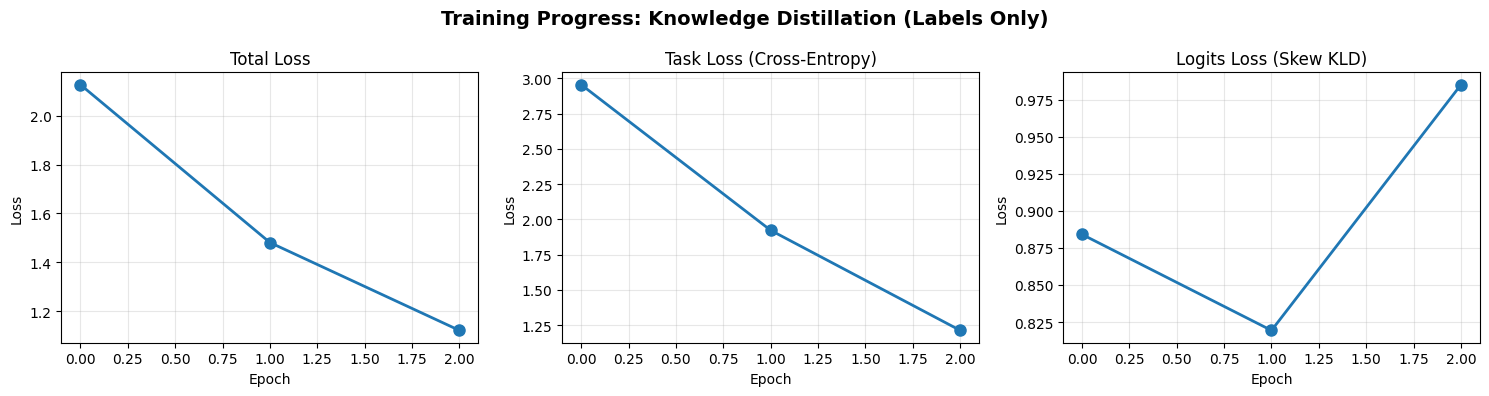

Plot saved to kd_training_curves.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_keys = [
    ("total",  "Total Loss"),
    ("task",   "Task Loss (Cross-Entropy)"),
    ("logits", "Logits Loss (Skew KLD)"),
]

for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(
        stats['loss_history'][key],
        marker='o', linewidth=2, markersize=8
    )
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    'Training Progress: Knowledge Distillation (Labels Only)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('kd_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to kd_training_curves.png")

## 6. Save Student to Hugging Face (Private) + Clear Memory

We push the trained student to a private HF repository, then free **all** GPU memory
(both teacher and student). This ensures each model's performance is measured in isolation:
the teacher was measured in Section 1 on a clean GPU; the student will be measured in
Section 9 after downloading from HF, also on a clean GPU.

This step also serves as an **end-to-end validation**: the benchmarks in Section 7 will run
against the model downloaded from HF, confirming that save + load works correctly.

In [14]:
import gc

# --- Configure your HF repo name ---
HF_MODEL_NAME = "oopere/qwen3-5-student"  # <-- change to your HF username

# 1. Push trained student (private)
print(f"Pushing student to HF: {HF_MODEL_NAME} (private)...")
trained_student.push_to_hub(HF_MODEL_NAME, private=True)
tokenizer.push_to_hub(HF_MODEL_NAME)
print("  ✓ Student uploaded successfully")

# 2. Delete student from memory — teacher stays
del trained_student, student_model, student_to_train
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print("  ✓ Student removed from GPU memory (teacher still loaded)")

# Verify teacher is still in memory
print(f"  Teacher layers in memory: {teacher_model.config.num_hidden_layers}")
if torch.cuda.is_available():
    used_gb = torch.cuda.memory_allocated() / 1e9
    print(f"  GPU memory used: {used_gb:.2f} GB")

Pushing student to HF: oopere/qwen3-5-student (private)...


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpzg7eu1j4/tokenizer.json: 100%|##########| 20.0MB / 20.0MB            

No files have been modified since last commit. Skipping to prevent empty commit.


  ✓ Student uploaded successfully
  ✓ Student removed from GPU memory (teacher still loaded)
  Teacher layers in memory: 24
  GPU memory used: 1.52 GB


## 7. Load Student from HF + Benchmarks

Download the student from HF and evaluate it on 5 standard benchmarks using `lm-eval`.
Teacher scores are hardcoded from a reference run on the same GPU environment
(Qwen3.5-0.8B-Base, A100 40GB, full dataset).

**Why download instead of using the model already in memory?**
This confirms the full serialization pipeline (prune → distill → save → load) works
end-to-end, exactly as a downstream user would experience it.

In [15]:
!pip install -q lm-eval langdetect
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

In [16]:
!pip install -q codecarbon
from utils import model_evaluation, clear_gpu_cache
LIMIT_BENCHMARK=400

# Teacher reference scores (Qwen3.5-0.8B-Base, full benchmark run)
TEACHER_SCORES = {
    'arc_easy':       67.5,
    'winogrande':     59.4,
    'hellaswag':      54.9,
    'lambada_openai': 50.9,
    'piqa':           71.5,
}
BENCHMARK_TASKS = list(TEACHER_SCORES.keys())

# Load student from HF
print(f"Loading student from HF: {HF_MODEL_NAME}...")
student_eval = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)
student_eval.eval()
n_student_layers_eval = student_eval.config.num_hidden_layers
print(f"  ✓ Student loaded: {n_student_layers_eval} layers, {student_eval.num_parameters():,} params")

# Run benchmarks
print("\nRunning benchmarks on student (this takes ~10-20 min)...")
student_bench_raw = model_evaluation(
    student_eval, tokenizer, BENCHMARK_TASKS, limit=LIMIT_BENCHMARK, device=str(device), batch_size=8
)

# Extract accuracy scores (lm-eval returns nested dicts)
def extract_acc(results, task):
    r = results.get(task, {})
    for k in ('accuracy', 'acc_norm', 'acc'):  # priority order
        if k in r:
            return float(r[k]) * 100
    return 0.0

student_scores = {t: extract_acc(student_bench_raw, t) for t in BENCHMARK_TASKS}

print("\nBenchmark results:")
print(f"{'Task':<20} {'Teacher':>10} {'Student':>10} {'Retention':>12}")
print("-" * 55)
for task in BENCHMARK_TASKS:
    t = TEACHER_SCORES[task]
    s = student_scores[task]
    ret = (s / t * 100) if t > 0 else 0
    print(f"{task:<20} {t:>9.1f}% {s:>9.1f}% {ret:>10.1f}%")

avg_teacher = sum(TEACHER_SCORES.values()) / len(TEACHER_SCORES)
avg_student = sum(student_scores.values()) / len(student_scores)
cap_retention = avg_student / avg_teacher * 100
print(f"{'AVERAGE':<20} {avg_teacher:>9.1f}% {avg_student:>9.1f}% {cap_retention:>10.1f}%")

Loading student from HF: oopere/qwen3-5-student...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.08G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/183 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 5198/5198 [08:51<00:00,  9.77it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 152.83it/s]



Benchmark results:
Task                    Teacher    Student    Retention
-------------------------------------------------------
arc_easy                  67.5%      48.0%       71.1%
winogrande                59.4%      53.8%       90.5%
hellaswag                 54.9%      36.8%       66.9%
lambada_openai            50.9%      29.5%       58.0%
piqa                      71.5%      59.2%       82.9%
AVERAGE                   60.8%      45.5%       74.7%


## 8. Retention Chart

Visual summary of PPL retention, capabilities retention, and overall retention
for Teacher, Pruned (no KD), and Trained Student.

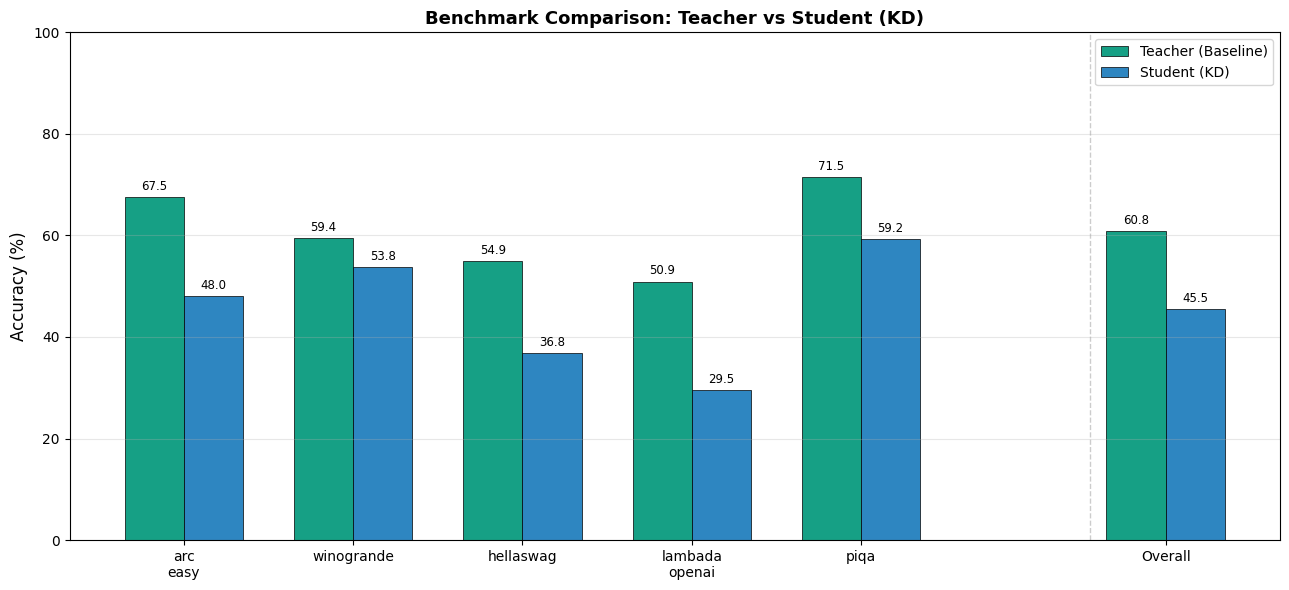

In [17]:
# 8. Benchmark Comparison Chart
import numpy as np

tasks = list(TEACHER_SCORES.keys())
teacher_vals = [TEACHER_SCORES[t] for t in tasks]
student_vals  = [student_scores[t] for t in tasks]

# Add Overall group
tasks_plot        = tasks + ['overall']
teacher_vals_plot = teacher_vals + [avg_teacher]
student_vals_plot = student_vals  + [avg_student]

# x positions — extra gap before Overall
n_tasks  = len(tasks)
x_tasks  = np.arange(n_tasks)
x_overall = np.array([n_tasks + 0.8])   # wider gap here
x_all     = np.concatenate([x_tasks, x_overall])

width   = 0.35
COLOR_TEACHER = '#16a085'
COLOR_STUDENT = '#2e86c1'

fig, ax = plt.subplots(figsize=(13, 6))

bars_t = ax.bar(x_all - width/2, teacher_vals_plot, width,
                label='Teacher (Baseline)', color=COLOR_TEACHER,
                edgecolor='black', linewidth=0.5)
bars_s = ax.bar(x_all + width/2, student_vals_plot, width,
                label='Student (KD)', color=COLOR_STUDENT,
                edgecolor='black', linewidth=0.5)

# Annotations
for bar in list(bars_t) + list(bars_s):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8.5)

# Vertical separator before Overall
ax.axvline(x=n_tasks + 0.35, color='#aaaaaa', linestyle='--', linewidth=1, alpha=0.6)

labels = [t.replace('_', '\n') for t in tasks] + ['Overall']
ax.set_xticks(x_all)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Benchmark Comparison: Teacher vs Student (KD)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Performance Metrics (VRAM + Tokens/sec)

Measure memory footprint and throughput for the **student** model.
We use `measure_memory_allocation` (static VRAM + dynamic delta from KV cache)
and `measure_detailed_performance` (tokens per second) from `utils.py`.

**The teacher was measured in Section 1 immediately after loading (clean GPU).
The student is measured here after downloading from HF (also on a clean GPU).
This ensures each measurement is taken in isolation for a fair, uncontaminated comparison.**

In [18]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
# Rebuild perf loader — tokenizer was re-loaded in Section 7
perf_enc = tokenizer(
    PERF_SENTENCES,
    padding=True, truncation=True, max_length=64, return_tensors="pt"
)
perf_dataset     = TensorDataset(perf_enc["input_ids"], perf_enc["attention_mask"])
perf_loader      = DataLoader(perf_dataset, batch_size=2)
perf_dict_loader = DictLoader(perf_loader)

# Measure student performance (clean GPU — teacher is no longer in memory)
print("Measuring VRAM (student)...")
student_vram = measure_memory_allocation(
    student_eval, tokenizer, PERF_PROMPT, max_new_tokens=PERF_MAX_NEW_TOKENS
)
print("Measuring tokens/sec (student)...")
student_perf = measure_detailed_performance(
    student_eval, tokenizer, perf_dict_loader,
    num_runs=PERF_NUM_RUNS, max_new_tokens=PERF_MAX_NEW_TOKENS, max_samples=PERF_MAX_SAMPLES
)
print(f"  Student VRAM (static): {student_vram['static_vram_mb']:.0f} MB")
print(f"  Student throughput:    {student_perf['throughput_tokens_per_sec']:.1f} tok/s")

Measuring VRAM (student)...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Measuring tokens/sec (student)...
🚀 Optimization active: Using Mixed Precision (torch.bfloat16) if available.
Measuring performance on 5 batches (Total samples: 10, 3 runs each)...
   🔥 Performing GPU Warm-up...


Performance test:   0%|          | 0/5 [00:00<?, ?it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Performance test:  20%|██        | 1/5 [00:00<00:01,  2.67it/s]A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only ar

  Student VRAM (static): 2482 MB
  Student throughput:    52.0 tok/s


## 10. Summary Table

Full comparison: Teacher vs Student across quality, capability, and efficiency metrics.

In [19]:
param_reduction = (
    (teacher_n_params - student_eval.num_parameters())
    / teacher_n_params * 100
)

rows = [
    ('Layers',           f"{n_teacher_layers}",                   f"{student_eval.config.num_hidden_layers}"),
    ('Parameters',       f"{teacher_n_params/1e6:.0f}M",          f"{student_eval.num_parameters()/1e6:.0f}M"),
    ('Param Reduction',  '—',                                               f"{param_reduction:.1f}%"),
]

# Benchmarks
for task in BENCHMARK_TASKS:
    rows.append((task.replace('_', ' ').title(),
                 f"{TEACHER_SCORES[task]:.1f}%",
                 f"{student_scores[task]:.1f}%"))

rows.append(('Avg Benchmark',
             f"{avg_teacher:.1f}%",
             f"{avg_student:.1f}% ({cap_retention:.1f}% retained)"))

# VRAM
rows.append(('Static VRAM',
             f"{teacher_vram['static_vram_mb']:.0f} MB",
             f"{student_vram['static_vram_mb']:.0f} MB"))
rows.append(('Dynamic VRAM (KV cache delta)',
             f"{teacher_vram['dynamic_delta_mb']:.0f} MB",
             f"{student_vram['dynamic_delta_mb']:.0f} MB"))

# TPS
rows.append(('Throughput (tok/s)',
             f"{teacher_perf['throughput_tokens_per_sec']:.1f}",
             f"{student_perf['throughput_tokens_per_sec']:.1f}"))
rows.append(('Avg Latency (s)',
             f"{teacher_perf['avg_latency_sec']:.3f}",
             f"{student_perf['avg_latency_sec']:.3f}"))

# Print table
col_w = [35, 22, 36]
sep   = '+' + '+'.join('-' * (w + 2) for w in col_w) + '+'
header = f"| {'Metric':<{col_w[0]}} | {'Teacher':^{col_w[1]}} | {'Student (KD)':^{col_w[2]}} |"
print(sep); print(header); print(sep)
for label, t_val, s_val in rows:
    print(f"| {label:<{col_w[0]}} | {t_val:^{col_w[1]}} | {s_val:^{col_w[2]}} |")
print(sep)

+-------------------------------------+------------------------+--------------------------------------+
| Metric                              |        Teacher         |             Student (KD)             |
+-------------------------------------+------------------------+--------------------------------------+
| Layers                              |           24           |                  14                  |
| Parameters                          |          752M          |                 540M                 |
| Param Reduction                     |           —            |                28.2%                 |
| Arc Easy                            |         67.5%          |                48.0%                 |
| Winogrande                          |         59.4%          |                53.8%                 |
| Hellaswag                           |         54.9%          |                36.8%                 |
| Lambada Openai                      |         50.9%          |